In [1]:
import os
os.getcwd()
os.chdir("/Users/caropark/FAO_ag_check_code/")

In [2]:
import pandas as pd
import numpy as np
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [3]:
fig4 = pd.read_csv("./data/fig4_adjr2.csv")
gdp = pd.DataFrame(pd.read_csv("./data/wb_gdp_per_cap.csv")[['iso_a3', 'value']])
fig4df = pd.merge(fig4, gdp, on="iso_a3")

# Pivot to wide format and compute difference
wide = fig4df.pivot(index=['iso_a3', 'value'], columns='model', values='adj_r2').reset_index()
wide.columns.name = None
wide = wide.rename(columns={'value': 'gdp_per_cap'})
wide['diff'] = wide['Satellite'] - wide['Survey']
wide['log_gdp'] = np.log(wide['gdp_per_cap'])


In [4]:
import pycountry

def iso2_to_iso3(iso2):
    try:
        return pycountry.countries.get(alpha_2=iso2).alpha_3
    except:
        return None

centroids = pd.read_csv("https://raw.githubusercontent.com/gavinr/world-countries-centroids/master/dist/countries.csv")
centroids['iso_a3'] = centroids['ISO'].apply(iso2_to_iso3)
centroids = centroids.dropna(subset=['iso_a3'])

wide = wide.merge(centroids[['iso_a3', 'latitude']], on='iso_a3', how='left')
print(wide['latitude'].isna().sum(), "missing latitudes")
wide['tropical'] = wide['latitude'].abs() <= 23.5
print(wide['tropical'].value_counts())

1 missing latitudes
False    86
True     83
Name: tropical, dtype: int64


In [5]:
# Clean
mask = np.isfinite(wide['log_gdp']) & np.isfinite(wide['diff'])
wide = wide[mask].copy()

# --- Regression 1: overall ---
X = sm.add_constant(wide['log_gdp'])
model = sm.OLS(wide['diff'], X).fit()
print("=== Overall ===")
print(f"  β = {model.params['log_gdp']:.3f}, p = {model.pvalues['log_gdp']:.3f}, N = {len(wide)}")

# --- Regression 2: tropical vs non-tropical ---
print("\n=== By tropical status ===")
for group, label in [(True, 'Tropical'), (False, 'Non-tropical')]:
    sub = wide[wide['tropical'] == group].copy()
    sub_mask = np.isfinite(sub['log_gdp']) & np.isfinite(sub['diff'])
    sub = sub[sub_mask]
    X_ = sm.add_constant(sub['log_gdp'])
    m = sm.OLS(sub['diff'], X_).fit()
    print(f"  {label}: β = {m.params['log_gdp']:.3f}, p = {m.pvalues['log_gdp']:.3f}, N = {len(sub)}")

# --- Regression 3: joint model with tropical dummy ---
wide['tropical_int'] = wide['tropical'].astype(int)
X2 = sm.add_constant(wide[['log_gdp', 'tropical_int']])
model2 = sm.OLS(wide['diff'], X2).fit()
print("\n=== Joint model (log GDP + tropical dummy) ===")
print(model2.summary())


=== Overall ===
  β = -0.025, p = 0.016, N = 168

=== By tropical status ===
  Tropical: β = -0.037, p = 0.087, N = 83
  Non-tropical: β = -0.025, p = 0.037, N = 85

=== Joint model (log GDP + tropical dummy) ===
                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     3.414
Date:                Sun, 08 Mar 2026   Prob (F-statistic):             0.0352
Time:                        11:15:48   Log-Likelihood:                 40.400
No. Observations:                 168   AIC:                            -74.80
Df Residuals:                     165   BIC:                            -65.43
Df Model:                           2                                         
Covariance Type:            nonrobust                                       

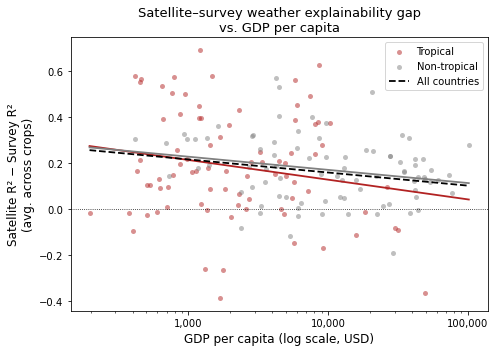

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

# Scatter points
for trop, label, color in [(True, 'Tropical', 'firebrick'), (False, 'Non-tropical', 'gray')]:
    sub = wide[wide['tropical'] == trop]
    ax.scatter(sub['gdp_per_cap'], sub['diff'], alpha=0.5, s=25,
               color=color, linewidths=0, label=label)

# Regression lines by group
x_range = np.linspace(wide['log_gdp'].min(), wide['log_gdp'].max(), 300)
for trop, color in [(True, 'firebrick'), (False, 'gray')]:
    sub = wide[wide['tropical'] == trop]
    X_ = sm.add_constant(sub['log_gdp'])
    m = sm.OLS(sub['diff'], X_).fit()
    y_hat = m.params['const'] + m.params['log_gdp'] * x_range
    ax.plot(np.exp(x_range), y_hat, color=color, linewidth=1.8)

# Overall regression line in black
X_all = sm.add_constant(wide['log_gdp'])
m_all = sm.OLS(wide['diff'], X_all).fit()
y_hat_all = m_all.params['const'] + m_all.params['log_gdp'] * x_range
ax.plot(np.exp(x_range), y_hat_all, color='black', linewidth=1.8, 
        linestyle='--', label='All countries')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')

ax.set_xlabel('GDP per capita (log scale, USD)', fontsize=12)
ax.set_ylabel('Satellite R² − Survey R²\n(avg. across crops)', fontsize=12)
ax.set_title('Satellite–survey weather explainability gap\nvs. GDP per capita', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig4_gdp_scatter.png')
plt.show()